# 05 - Explainability

Which features actually drive the tuned model's predictions, and why does it flag a particular
customer? This notebook uses SHAP on the saved pipeline, checks the picture against a
model-agnostic permutation importance, and walks through two individual customers. The helpers
in `src/explain.py` are the same ones the app uses to explain a score.

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.inspection import permutation_importance

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data import TARGET
from src.explain import encode, make_explainer, shap_values_for
from src.features import feature_names

FIG = PROJECT_ROOT / "reports" / "figures"
MODELS = PROJECT_ROOT / "models"
PROCESSED = PROJECT_ROOT / "data" / "processed"
sns.set_theme(style="whitegrid")

pipeline = joblib.load(MODELS / "churn_pipeline.joblib")
train = pd.read_csv(PROCESSED / "train.csv")
test = pd.read_csv(PROCESSED / "test.csv")
X_train, y_train = train.drop(columns=[TARGET]), train[TARGET]
X_test, y_test = test.drop(columns=[TARGET]), test[TARGET]
columns = feature_names(pipeline.named_steps["prep"])
print(type(pipeline.named_steps["clf"]).__name__, "with", len(columns), "features")

RandomForestClassifier with 29 features


## SHAP values on the test split

`TreeExplainer` gives exact Shapley values for the forest. Each value is how much one feature
moved one customer's churn probability away from the base rate (the model's average output).

In [2]:
X_test_enc = encode(pipeline, X_test)
explainer = make_explainer(pipeline)
shap_values = shap_values_for(explainer, X_test_enc)
proba = pipeline.predict_proba(X_test)[:, 1]
print("shap matrix", shap_values.shape)
print("base value", np.round(np.atleast_1d(explainer.expected_value)[-1], 4))

shap matrix (1409, 29)
base value 0.4998


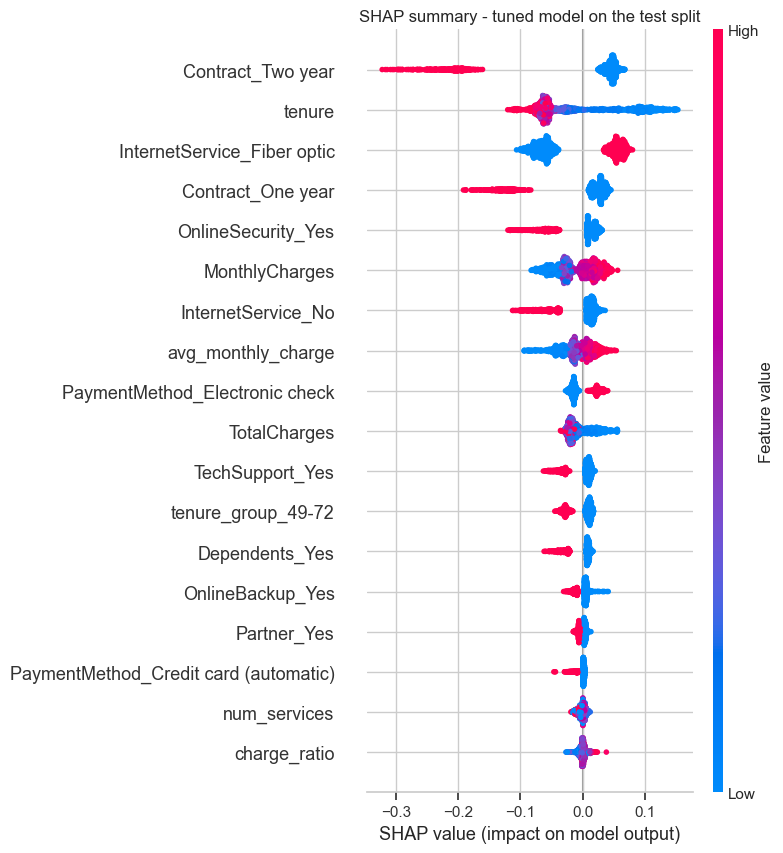

In [3]:
fig = plt.figure(figsize=(8, 8))
shap.summary_plot(shap_values, X_test_enc, feature_names=columns, max_display=18, show=False)
plt.title("SHAP summary - tuned model on the test split")
plt.tight_layout()
plt.savefig(FIG / "18_shap_summary.png", dpi=120, bbox_inches="tight")

Contract_Two year                 0.0864
tenure                            0.0665
InternetService_Fiber optic       0.0615
Contract_One year                 0.0484
OnlineSecurity_Yes                0.0298
MonthlyCharges                    0.0274
InternetService_No                0.0248
avg_monthly_charge                0.0200
PaymentMethod_Electronic check    0.0183
TotalCharges                      0.0178
TechSupport_Yes                   0.0173
tenure_group_49-72                0.0161
dtype: float64

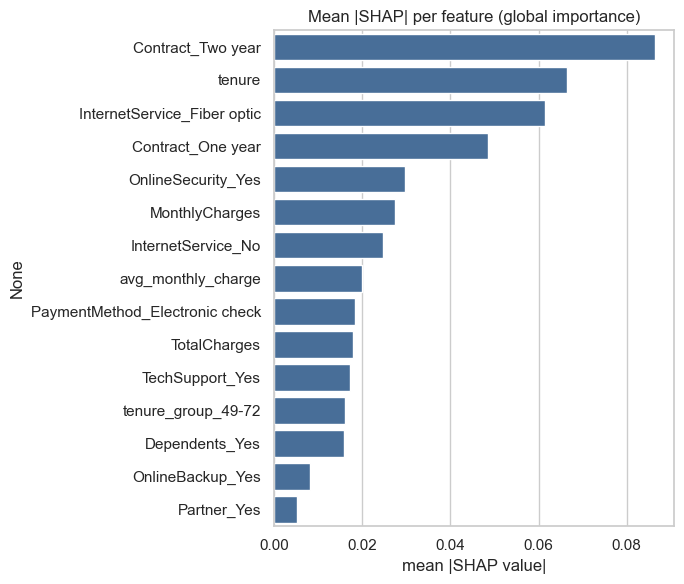

In [4]:
mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 6))
sns.barplot(x=mean_abs.head(15).values, y=mean_abs.head(15).index, ax=ax, color="#3b6ea5")
ax.set_title("Mean |SHAP| per feature (global importance)")
ax.set_xlabel("mean |SHAP value|")
fig.tight_layout()
fig.savefig(FIG / "19_shap_bar.png", dpi=120)
mean_abs.head(12).round(4)

The two contract dummies together are the biggest lever: being on a two-year contract pulls a
customer's churn probability down by up to 0.3, a one-year contract by about 0.2. `tenure` is
next, then the fiber optic flag - fiber pushes probability *up* in every single case (the red
cluster to the right) - and `OnlineSecurity_Yes`, which is protective. The charge columns come
after that, and the tail of the ranking (`gender`, `PhoneService`, the streaming add-ons,
`charge_ratio`) barely registers, which matches the mutual-information ranking from notebook 03.
The `num_services` count I engineered adds little once the individual add-on flags are in the
model.

## Dependence plots

How the contribution of a feature changes with its value. The x-axis is the standardised
feature (the model sees scaled inputs); the colour shows an interacting feature that SHAP
picks automatically.

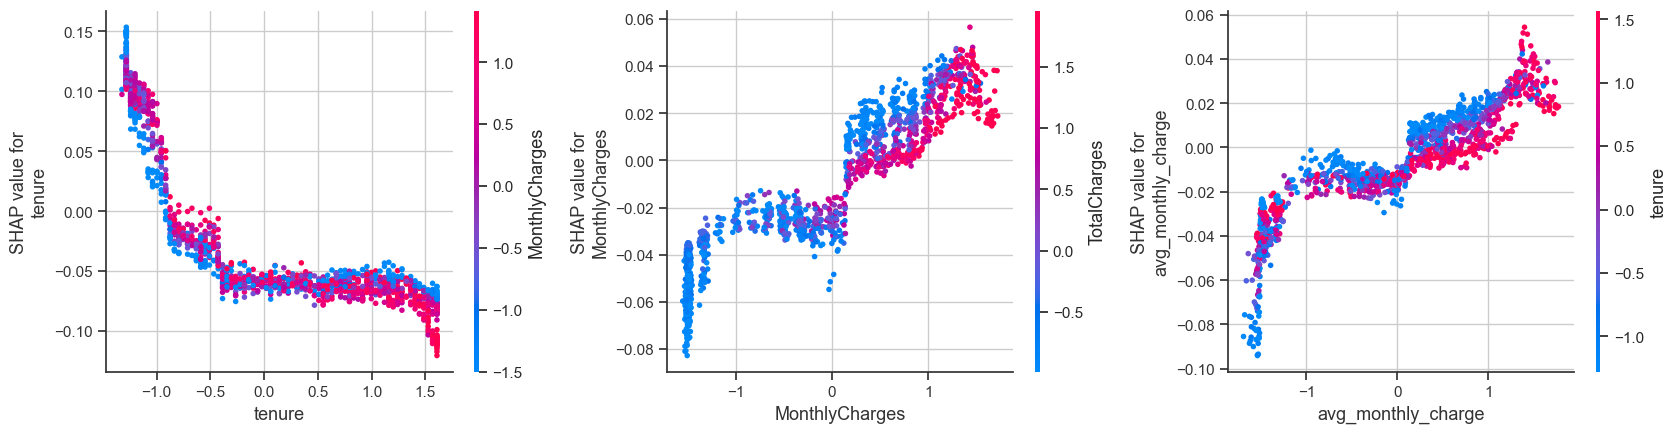

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, feat in zip(axes, ["tenure", "MonthlyCharges", "avg_monthly_charge"]):
    shap.dependence_plot(feat, shap_values, X_test_enc, feature_names=columns, ax=ax, show=False)
fig.tight_layout()
fig.savefig(FIG / "20_shap_dependence.png", dpi=120)

Tenure is not linear: the SHAP value drops steeply through the first year (roughly the
standardised range -1.3 to -0.7) and is flat after that, so the model has learned the "first
twelve months are the risk window" pattern from the EDA rather than a gradual decline. Monthly
charge is close to monotonic - higher bills push towards churn - with a knee around the mean,
and the colour shows the interaction: for the same monthly price, customers with a low
`TotalCharges` (i.e. new) get the larger push. `avg_monthly_charge` carries the same story from
the other side.

## Two customers, explained

A waterfall plot for the customer the model is most sure will churn, and for one it is most
sure will stay.

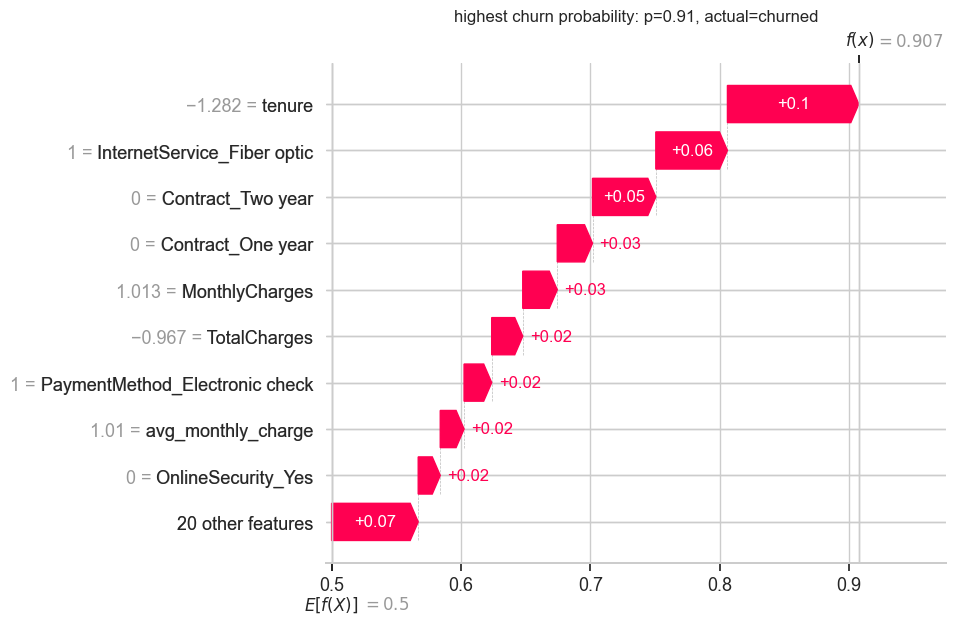

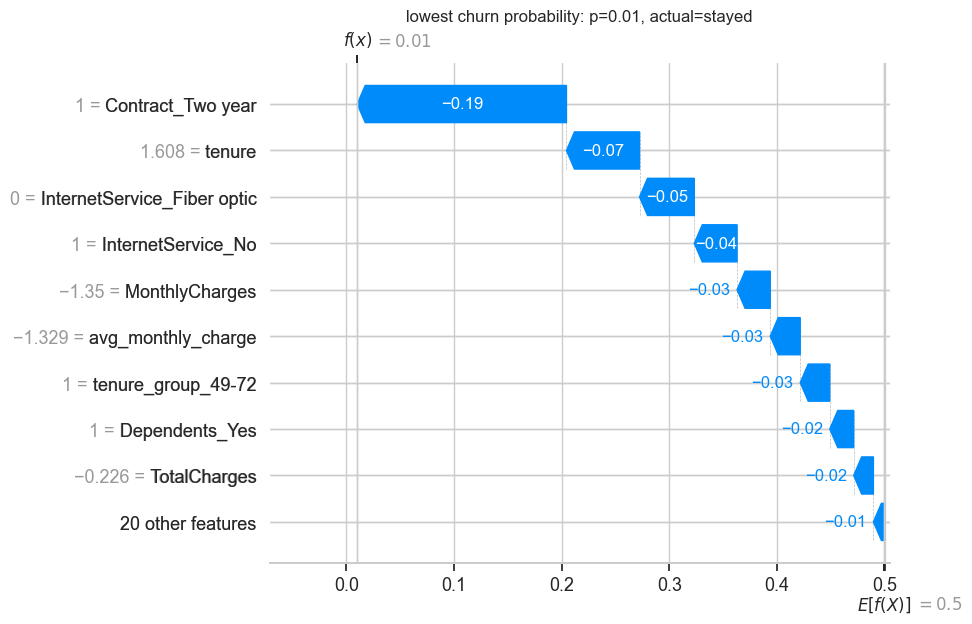

,tenure,Contract,InternetService,PaymentMethod,MonthlyCharges,OnlineSecurity,TechSupport,num_services,churn_probability
1221,1,Month-to-month,Fiber optic,Electronic check,95.45,No,No,2,0.907
475,72,Two year,No,Credit card (automatic),24.25,No,No,0,0.010


In [6]:
idx_churn = int(np.argmax(proba))
idx_stay = int(np.argmin(proba))
base = float(np.atleast_1d(explainer.expected_value)[-1])

for idx, label, fname in [(idx_churn, "highest churn probability", "21_local_churner.png"), (idx_stay, "lowest churn probability", "21_local_loyal.png")]:
    plt.figure(figsize=(8, 5.5))
    exp = shap.Explanation(values=shap_values[idx], base_values=base, data=X_test_enc.iloc[idx].values, feature_names=columns)
    shap.plots.waterfall(exp, max_display=10, show=False)
    plt.title(f"{label}: p={proba[idx]:.2f}, actual={'churned' if y_test.iloc[idx] else 'stayed'}")
    plt.savefig(FIG / fname, dpi=120, bbox_inches="tight")
    plt.show()

X_test.iloc[[idx_churn, idx_stay]][["tenure", "Contract", "InternetService", "PaymentMethod", "MonthlyCharges", "OnlineSecurity", "TechSupport", "num_services"]].assign(churn_probability=proba[[idx_churn, idx_stay]].round(3))

The two waterfalls read like the EDA profile. The 91%-probability customer is one month in, on
fiber, month-to-month, paying $95 by electronic check with no security add-on; every one of the
top contributions pushes the same way. The 1%-probability customer is the mirror image: 72
months on a two-year contract with no internet service and a $24 bill. For the app this is the
useful part - the same per-feature contributions are shown next to every score, so a retention
agent can see *why* a customer was flagged and not just that they were.

## Cross-check: permutation importance

SHAP explains the model; permutation importance asks a different question - how much does
test-set ROC-AUC fall when a raw column is shuffled? It runs on the raw (pre-encoding) columns
through the whole pipeline, so the one-hot dummies of a categorical are shuffled together.

In [7]:
perm = permutation_importance(pipeline, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=42, n_jobs=1)
perm_df = pd.DataFrame({"mean_drop": perm.importances_mean, "std": perm.importances_std}, index=X_test.columns).sort_values("mean_drop", ascending=False)
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(perm_df.head(15).index[::-1], perm_df.head(15)["mean_drop"][::-1], xerr=perm_df.head(15)["std"][::-1], color="#dd8452")
ax.set_title("Permutation importance (drop in test ROC-AUC)")
fig.tight_layout()
fig.savefig(FIG / "22_permutation_importance.png", dpi=120)
perm_df.head(12).round(4)

,mean_drop,std
Contract,0.0728,0.0075
InternetService,0.0295,0.0059
tenure,0.0267,0.0021
TotalCharges,0.0050,0.0009
PaymentMethod,0.0040,0.0011
MonthlyCharges,0.0037,0.0027
OnlineSecurity,0.0035,0.0014
TechSupport,0.0033,0.0015
avg_monthly_charge,0.0031,0.0020
tenure_group,0.0021,0.0008


The permutation ranking agrees with SHAP on the top three - contract, internet service and
tenure - and confirms they are the only features whose removal costs more than half a point of
ROC-AUC. Everything below `TotalCharges` is worth at most 0.5 points each; the model would lose
very little if the bottom half of the columns were dropped, which is a reasonable simplification
if this were ever deployed against a live feed with less complete data.